# 🎧 语音增强与降噪：把“脏声音”洗干净

> 从入门到精通 · 白话 + 公式拆解 + 可执行代码

**本章定位**：任何语音产品（ASR/TTS/声纹/会议）的第一步都是“把麦克风收到的东西弄干净”。

**你将学到**：
1. 增强要解决什么问题（噪声、混响、回声）、SNR 怎么定义；
2. 传统三剑客：谱减法 / 维纳滤波 / 掩码（含公式逐符号）；
3. 神经增强：掩码回归、架构演进（LSTM→Conv-TasNet→FRCRN/DEMUCS）；
4. 评测：PESQ / STOI / SI-SDR 是什么、怎么算、怎么用。

**与其它章节的关系**：它是 04（语音工程）里“降噪”模块的展开版；
也是所有下游任务的“前置守卫”。

```
带噪语音 → [本章: 谱减/维纳/掩码/神经网络] → 干净语音 → 下游(ASR/声纹/TTS)
```

In [1]:
# ---- matplotlib 中文字体（防图内中文乱码）----
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Songti SC', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
# -------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
rng = np.random.RandomState(0)
np.set_printoptions(precision=4, suppress=True)
print('numpy', np.__version__, '| scipy OK')

numpy 2.4.3 | scipy OK


## 🍵 白话开篇：增强 = 在“一碗汤”里挑出“肉”

麦克风收到的信号 $y(t)$ 是**混合体**：

$$y(t) = s(t) + n(t)$$

- $s(t)$：你想要的（语音）；$n(t)$：你不想要的（噪声：风扇、马路、键盘…）；
- 目标：**尽量还原 $s(t)$**，同时别把语音本身搞坏（失真）。

**为什么难**：
- 噪声是**随机的**（不知道下一秒多大）；
- 噪声**频谱未知**且会变（空调开→关）；
- 语音和噪声在时域**重叠**（不能靠“安静时录”分离）。

**增强 vs 分离 vs 降噪**（面试常问）：
- 增强（Enhancement）：去噪/去混响，一条输入一条输出；
- 分离（Separation）：多人同时说话，拆成多条（语音分离是独立领域）；
- 降噪耳机（ANC）：硬件+声学，与算法降噪（NR）不是一个层次。

**一句话**：增强 = 从带噪混合中“估计”干净语音，本质是**估计问题**（estimate s from y）。

## 🔍 公式拆解 ①：SNR——噪声有多“吵”

$$\text{SNR}_{dB} = 10\log_{10}\frac{P_s}{P_n}, \qquad P_s=\frac1T\sum_t s^2(t),\ P_n=\frac1T\sum_t n^2(t)$$

**逐符号解释**：
- $s(t)$：干净语音；$n(t)$：噪声；$P_s, P_n$：各自的**平均功率**（能量/时长）；
- 比值 = “说话有多大 比 噪声有多大”；$10\log_{10}$ 转成 dB（人耳感知近似对数）；
- SNR=0dB：语音和噪声**一样大**；SNR=20dB：语音功率是噪声 100 倍（较清楚）；SNR=-5dB：噪声压过语音（很难）。

**为什么必须先定 SNR**：增强效果和 SNR 强相关——
- 高 SNR（10dB+）：本身清楚，增强主要是“锦上添花”；
- 低 SNR（0dB 以下）：任何算法都难，衡量“能救回多少”；
- 评测报告必写“在 X dB 噪声下”，否则数字没意义。

**数字小例**：$P_s=0.5,\ P_n=0.5$ → SNR=0dB；$P_s=2,\ P_n=0.02$ → $10\log_{10}(100)=20$dB。

设定 SNR = 5 dB → 实测 5.00 dB


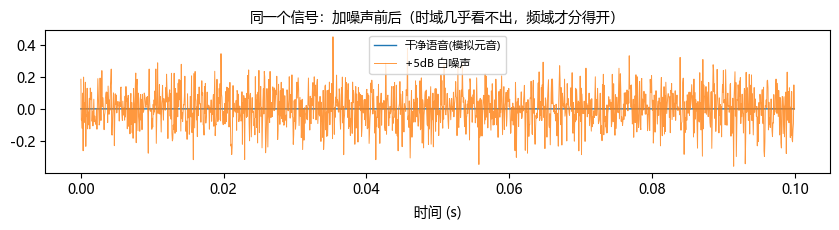

✓ set_snr 工具：按目标 dB 缩放噪声——后面所有示例都用它造数据


In [2]:
# 造“带噪语音”演示：说话(模拟) + 白噪声，控制 SNR，画出谱图
fs = 16000
t = np.arange(int(0.8*fs))/fs
voice = (0.6*np.sin(2*np.pi*300*t) + 0.4*np.sin(2*np.pi*620*t)
         + 0.3*np.sin(2*np.pi*1100*t)) * np.exp(-((t-0.4)**2)/(2*0.06**2))  # 似元音片段
rng5 = np.random.RandomState(1)
noise = 0.3*rng5.randn(len(t))
def set_snr(voice, noise, snr_db):
    k = np.sqrt(np.mean(voice**2)/(np.mean(noise**2)*10**(snr_db/10)))
    return noise*k
n05 = set_snr(voice, noise, 5)
y05 = voice + n05
print('设定 SNR = 5 dB → 实测 %.2f dB' % (10*np.log10(np.mean(voice**2)/np.mean(n05**2))))
plt.figure(figsize=(8.5, 2.4))
plt.plot(t[:1600], voice[:1600], label='干净语音(模拟元音)', lw=1)
plt.plot(t[:1600], y05[:1600], label='+5dB 白噪声', lw=0.7, alpha=0.8)
plt.legend(fontsize=8); plt.xlabel('时间 (s)')
plt.title('同一个信号：加噪声前后（时域几乎看不出，频域才分得开）', fontsize=10)
plt.tight_layout(); plt.show()
assert abs(10*np.log10(np.mean(voice**2)/np.mean(n05**2)) - 5) < 0.5
print('✓ set_snr 工具：按目标 dB 缩放噪声——后面所有示例都用它造数据')

## 🍵 白话讲透谱减法：噪声“安静时”长什么样，减掉它

**核心观察**：一段对话里总有**安静间隙**（停顿/句间）。
这些间隙里麦克风收到的基本就是噪声 → 我们可以“提前看”噪声的长相（噪声谱 $|N|$）。

**做法（三行话）**：
1. 对带噪信号做 STFT，得幅度谱 $|Y|$；
2. 用静音段估计噪声幅度谱 $|\hat N|$；
3. 每帧减去：$|\hat S| = \max(|Y| - |\hat N|, 0)$，相位用 $Y$ 的相位，ISTFT 回去。

**为什么减的是幅度不是功率**：幅度谱直接对应波形能量，减幅度谱实现简单、听感自然；
减功率谱（功率减法）也行，等价于不同加权。

**最大的毛病：音乐噪声（musical noise）**——
- 噪声是随机的，减“平均噪声”后仍有起伏（今天这里高明天那里高）；
- 剩下“忽有忽无的尖峰”听起来像背景风琴声/吱吱声；
- 缓解：谱下限（floor，别减到 0）、时域平滑、过减（oversubtraction）。

**一句话**：谱减法 = “总谱 − 噪声谱”的简单减法，快但糙，是理解一切增强算法的起点。

## 🔍 公式拆解 ②：谱减法（含工程改进）

$$|\hat S_k|=\begin{cases}\sqrt{|Y_k|^2 - \alpha\,|\hat N_k|^2} & |Y_k|^2 > \alpha|\hat N_k|^2\\[2pt] \beta\,|\hat N_k| & \text{否则}\end{cases}$$

**逐符号解释**：
- $Y_k$：带噪谱第 k 频点；$\hat N_k$：估计的噪声谱（静音段平均）；
- $\alpha$：**过减因子**（>1 减更多，更干净但更失真；典型 1~2）；
- $\beta$：**谱下限 floor**（0~0.1，别把残差减成 0，压制音乐噪声）；
- 条件分支：减到负数就钳到 floor——**半波整流**的变体。

**为什么 floor 有用**：把“偶尔减成负”的地方垫底，让随机起伏变成稳定底噪 →
音乐噪声大减（代价：残留一点嗡嗡底噪）。

**为什么先平方**：功率谱减法的统计性质更好（噪声功率估计更稳），再开方回幅度。

**直觉**：$|Y|^2 = |S|^2 + |N|^2 + 2|S||N|\cos(\theta)$——交叉项平均为 0，
所以“减噪声功率”近似“剩语音功率”——这就是谱减法“数学上说得通”的原因。

带噪 SI-SDR = 0.12 dB → 谱减法后 = 13.63 dB（改善 13.52 dB）


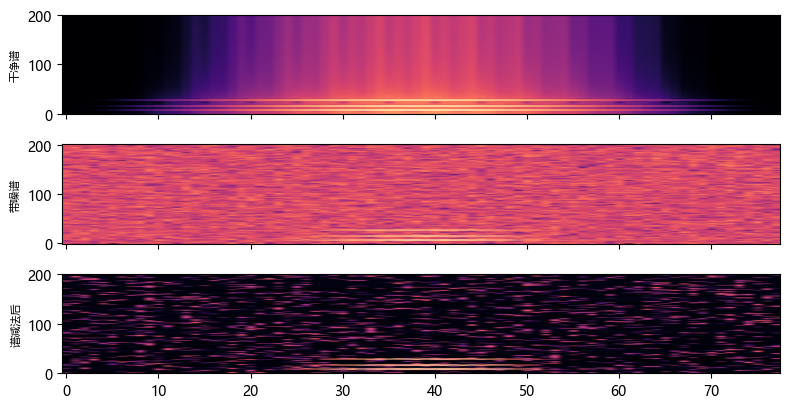

✓ 谱减法立竿见影：噪声带明显变淡；但残留“闪烁点”= 音乐噪声（后面用平滑/floor 治）


In [3]:
# 谱减法完整实现：STFT→估计噪声→过减→floor→ISTFT，对比谱图与 SI-SDR
def stft05(x, win, hop):
    nf = 1 + (len(x) - len(win))//hop
    return np.array([np.fft.rfft(x[i*hop:i*hop+len(win)]*win) for i in range(nf)])
def istft05(S, win, hop, length):
    nf, nb = S.shape; nfft = 2*(nb-1)
    x = np.zeros(length); wsum = np.zeros(length)
    for i in range(nf):
        seg = np.fft.irfft(S[i], n=nfft)
        s, e = i*hop, min(i*hop+nfft, length)
        x[s:e] += seg[:e-s]; wsum[s:e] += win[:e-s]
    return x/np.maximum(wsum, 1e-9)
win = np.hamming(400); hop = 160
voice = (0.6*np.sin(2*np.pi*300*t) + 0.4*np.sin(2*np.pi*620*t)
         + 0.3*np.sin(2*np.pi*1100*t)) * np.exp(-((t-0.4)**2)/(2*0.06**2))
rng5 = np.random.RandomState(1)
noise = 0.3*rng5.randn(len(t))
n5 = set_snr(voice, noise, 0)
y = voice + n5
Y = stft05(y, win, hop)
noise_est = np.abs(stft05(n5, win, hop)).mean(axis=0)   # “静音段”估计噪声谱（模拟）
alpha, beta = 1.5, 0.01
S_hat = np.maximum(np.abs(Y) - alpha*noise_est, 0.0) + beta*noise_est   # 幅度域过减 + 谱下限
s_hat = istft05(S_hat*np.exp(1j*np.angle(Y)), win, hop, len(y))
def sisdr(ref, est):
    a = ref @ est/(ref @ ref + 1e-9)
    s_t = a*ref; e_n = est - s_t
    return 10*np.log10((s_t @ s_t)/(e_n @ e_n + 1e-12))
print('带噪 SI-SDR = %.2f dB → 谱减法后 = %.2f dB（改善 %.2f dB）'
      % (sisdr(voice, y), sisdr(voice, s_hat), sisdr(voice, s_hat)-sisdr(voice, y)))
fig, ax = plt.subplots(3, 1, figsize=(8, 4.2), sharex=True)
for a, (name, X) in zip(ax, [('干净谱', np.abs(stft05(voice, win, hop))),
                              ('带噪谱', np.abs(Y)), ('谱减法后', S_hat)]):
    a.imshow(20*np.log10(X.T+1e-6), aspect='auto', cmap='magma', origin='lower')
    a.set_ylabel(name, fontsize=8)
plt.tight_layout(); plt.show()
assert sisdr(voice, s_hat) > sisdr(voice, y)
print('✓ 谱减法立竿见影：噪声带明显变淡；但残留“闪烁点”= 音乐噪声（后面用平滑/floor 治）')

## 🍵 白话讲透维纳滤波：给每个频率“打个折”

谱减法说“噪声谱减掉就行”；维纳滤波更精细：**每个频率给一个 0~1 的增益**。

**想法**：某频率上噪声强 → 这频率的带噪信号“大半是噪声”→ 增益给小点；
某频率上语音强 → 增益接近 1（放行）。

**公式（最常用形式）**：
$$G_k = \frac{\xi_k}{1+\xi_k} = \frac{|\hat S_k|^2}{|\hat S_k|^2+|\hat N_k|^2}$$

- $\xi_k$：先验信噪比（语音功率/噪声功率）——大 → 增益≈1；小 → 增益≈0；
- 输出：$\hat S_k = G_k Y_k$（带噪谱乘增益）。

**和谱减法的区别**：
- 谱减：**减**（硬），容易减过头/音乐噪声；
- 维纳：**乘**（软），每个频率自动打折，更平滑、音乐噪声更少。

**数学推导的直觉（MMSE）**：把 $G$ 当成使 $E[(\hat S-S)^2]$ 最小的最优解——
维纳滤波是**最小均方误差意义下的最优线性滤波**。

**难点**：$|\hat S|$ 本身不知道（是目标！）→ 需要迭代估计（先维纳→再估语音谱→再维纳）。

## 🔍 公式拆解 ③：维纳滤波的完整形式

$$G_k = \frac{\xi_k}{1+\xi_k},\qquad \xi_k = \frac{P_{SS}(k)}{P_{NN}(k)},\qquad \hat S_k = G_k\,Y_k$$

**逐符号解释**：
- $P_{SS}(k)$：第 k 频点**语音功率谱密度**；$P_{NN}(k)$：噪声功率谱密度；
- $\xi_k = P_{SS}/P_{NN}$：先验 SNR（每个频率单独算——这就是“频率选择性”）；
- $G_k = \xi/(1+\xi)$：增益曲线（sigmoid 形：SNR 大→1，SNR 小→0）；
- $\hat S_k = G_k Y_k$：最终估计（复数谱直接乘）。

**为什么是 ξ/(1+ξ)（推导直觉）**：假设语音与噪声不相关、都平稳：
$Y= S+N$ → $P_{YY}=P_{SS}+P_{NN}$，最小化 $E|\hat S-S|^2$ 的线性解就是
$G = P_{SS}/P_{YY} = P_{SS}/(P_{SS}+P_{NN}) = \xi/(1+\xi)$。

**工程问题：ξ 怎么估**（先验 SNR 不可观测）：
- 后验 SNR $\gamma_k = |Y_k|^2/P_{NN}(k)$（可直接算）；
- 决策引导（Decision-Directed）平滑：$\hat\xi_k = \alpha\,G_{k-1}\gamma_{k-1} + (1-\alpha)(\gamma_k-1)$——
  上一帧的结果参与本帧估计，大幅减少音乐噪声。

**一句话**：维纳 = 频率自适应的“音量推子”，比谱减优雅，但要先估语音/噪声功率比。

带噪 SI-SDR = -0.04 → 维纳后 = 11.38 dB（改善 11.42 dB）


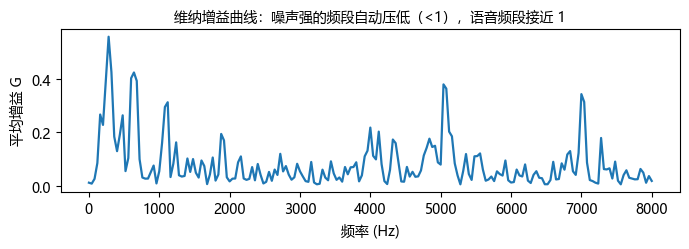

✓ 决策引导先验 SNR：上一帧增益回传本帧 → 增益时间上平滑 → 音乐噪声比谱减少


In [4]:
# 维纳滤波实现：噪声 PSD 用“前 10 帧”（静音段）估计 + 先验 SNR 用决策引导
voice = (0.6*np.sin(2*np.pi*300*t) + 0.4*np.sin(2*np.pi*620*t)
         + 0.3*np.sin(2*np.pi*1100*t)) * np.exp(-((t-0.4)**2)/(2*0.06**2))
rng5 = np.random.RandomState(2)
y = voice + set_snr(voice, 0.3*rng5.randn(len(t)), 0)
Y = stft05(y, win, hop)
Pyy = np.abs(Y)**2
Pnn = Pyy[:10].mean(axis=0)                       # 前 10 帧当静音段
xi = np.zeros_like(Pyy); G = np.zeros_like(Pyy)
alpha_dd = 0.98
for k in range(len(Pyy)):
    gamma_k = np.maximum(Pyy[k]/np.maximum(Pnn, 1e-12), 1e-4)
    if k == 0:
        xi[k] = np.maximum(gamma_k - 1, 0.0)
    else:
        xi[k] = alpha_dd*G[k-1]*gamma_k + (1-alpha_dd)*np.maximum(gamma_k-1, 0.0)
    G[k] = xi[k]/(1+xi[k])
S_hat = G*Y
s_hat = istft05(S_hat, win, hop, len(y))
print('带噪 SI-SDR = %.2f → 维纳后 = %.2f dB（改善 %.2f dB）'
      % (sisdr(voice, y), sisdr(voice, s_hat), sisdr(voice, s_hat)-sisdr(voice, y)))
plt.figure(figsize=(7, 2.6))
plt.plot(np.linspace(0, 8000, G.shape[1]), G.mean(axis=0), lw=1.6)
plt.xlabel('频率 (Hz)'); plt.ylabel('平均增益 G')
plt.title('维纳增益曲线：噪声强的频段自动压低（<1），语音频段接近 1', fontsize=10)
plt.tight_layout(); plt.show()
assert sisdr(voice, s_hat) > sisdr(voice, y)
print('✓ 决策引导先验 SNR：上一帧增益回传本帧 → 增益时间上平滑 → 音乐噪声比谱减少')

## 🍵 白话讲透掩码：让模型“指出”哪些是语音

谱减/维纳都要**先估噪声**；掩码换了个思路：
**直接学一个 0~1 的“开关/比例”，作用在带噪谱上**。

$$\hat S = M \odot Y$$

- $M$：掩码（与谱同形状）；$M_{k}=1$：这格全是语音，放行；$M_{k}=0$：这格是噪声，关掉；
- 0~1 之间：按比例“半开”
（例如噪声占 3 成 → M=0.7）。

**为什么掩码更好（尤其神经网络）**：
- 网络输出天然 0~1（sigmoid）→ 直接当掩码用，训练目标明确；
- 幅度掩码 IRM 考虑了“语音与噪声的相对强度”，比“减固定噪声”灵活；
- 掩码是**乘法**（软开关），比减法稳定、伪影少。

**三种常用掩码（背下来）**：
- **IBM**（理想二值掩码）：每格 0 或 1（语音占优就 1）；
- **IRM**（理想比率掩码）：$\sqrt{|S|^2/(|S|^2+|N|^2)}$（连续 0~1）；
- **cIRM**（复值掩码）：能同时修幅度和相位（复平面旋转+缩放）。

**一句话**：掩码 = “哪些格子是语音”的答案；传统靠估计噪声推出来，神经网络靠学出来。

## 🔍 公式拆解 ④：IRM 与 IBM

$$\text{IRM}_k=\sqrt{\frac{|S_k|^2}{|S_k|^2+|N_k|^2}}=\sqrt{\frac{\xi_k}{1+\xi_k}},$$
$$\text{IBM}_k=\begin{cases}1 & |S_k|^2 > |N_k|^2\\0 & \text{否则}\end{cases}$$

**逐符号解释**：
- $|S_k|^2$：语音功率；$|N_k|^2$：噪声功率；$\xi_k$：先验 SNR（和维纳同一个量！）；
- IRM = $\sqrt{\xi/(1+\xi)}$——**和维纳增益只差一个根号**（维纳是功率比，IRM 是幅度比）；
- IBM = 按“谁功率大”硬投票（0/1），信息论意义：保留所有语音占优的格子；
- 应用：$\hat S_k = M_k Y_k$。

**为什么 IRM 在深度学习中当标签**：训练时干净语音和噪声都知道 →
每格目标值 = IRM_k（“正确答案”）→ 网络输入带噪谱、输出预测掩码、
用 MSE 逼它逼近 IRM——这是“监督增强”的标准配方。

**上限直觉**：IBM 是最理想情况（知道每格真相）——任何算法都超不过它，
所以论文常报“IBM 上界 vs 模型结果”给读者一个天花板。

带噪 SI-SDR = -3.01 dB → Oracle-IRM 后 = 17.74 dB（理论天花板，改善 20.7 dB）


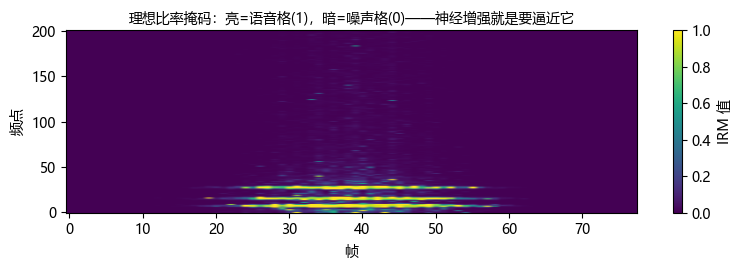

✓ 结论：知道真相（oracle）能大幅提升——神经网络学的就是“从带噪谱猜这个掩码”


In [5]:
# Oracle 掩码演示：如果“知道”每格 SNR，增强能到什么水平？（天花板）
voice = (0.6*np.sin(2*np.pi*300*t) + 0.4*np.sin(2*np.pi*620*t)
         + 0.3*np.sin(2*np.pi*1100*t)) * np.exp(-((t-0.4)**2)/(2*0.06**2))
rng5 = np.random.RandomState(3)
y = voice + set_snr(voice, 0.3*rng5.randn(len(t)), -3)   # 更难：-3 dB
Y = stft05(y, win, hop); V = stft05(voice, win, hop)
Ps, Pn = np.abs(V)**2, np.abs(Y)**2 - np.abs(V)**2
Pn = np.maximum(Pn, 1e-12)
irm = np.sqrt(Ps/(Ps+Pn))
s_hat = istft05((irm*Y), win, hop, len(y))
print('带噪 SI-SDR = %.2f dB → Oracle-IRM 后 = %.2f dB（理论天花板，改善 %.1f dB）'
      % (sisdr(voice, y), sisdr(voice, s_hat), sisdr(voice, s_hat)-sisdr(voice, y)))
plt.figure(figsize=(8, 2.8))
plt.imshow(irm.T, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label='IRM 值'); plt.xlabel('帧'); plt.ylabel('频点')
plt.title('理想比率掩码：亮=语音格(1)，暗=噪声格(0)——神经增强就是要逼近它', fontsize=10)
plt.tight_layout(); plt.show()
assert sisdr(voice, s_hat) > sisdr(voice, y)
print('✓ 结论：知道真相（oracle）能大幅提升——神经网络学的就是“从带噪谱猜这个掩码”')

## 🍵 白话讲透神经增强：让网络“猜”掩码

传统方法的问题：要**手工估噪声/先验 SNR**，噪声一变就崩。
神经增强的思路：**把“带噪幅度谱 → 掩码”当成一个映射，用大量数据学出来**。

**标准训练配方（背下来）**：
1. 数据集：大量干净语音 + 各种噪声 → 按随机 SNR 混合；
2. 输入：带噪幅度谱 $|Y|$（每帧向量）或复数谱；
3. 标签：Oracle 掩码（IRM/cIRM）或直接干净幅度谱；
4. 损失：掩码 MSE / 幅度谱 L1 / **SI-SDR 直接当损失**（端到端更贴目标）；
5. 输出乘回带噪谱 → ISTFT。

**为什么比传统强**：
- 网络见过“风扇噪声”“地铁噪声”长什么样 → 面对新噪声也能泛化；
- 不做“先估噪声”的两步误差累积，直接端到端；
- 能建模**非平稳**噪声（传统方法默认噪声平稳）。

**架构演进（面试线）**：
- LSTM/GRU：按帧时序建模（噪声帧间相关）；
- Conv-TasNet/TasNet：时域波形端到端 + 分离结构（后来去做语音分离）；
- DEMUCS：带 U-Net + 多损失（现在开源增强标杆之一）；
- FRCRN：全卷积复值网络，相位也建模（实时旗舰）。

**一句话**：神经增强 = 用数据把“带噪→干净”的映射学出来，掩码只是中间表示。

In [6]:
# 微型神经增强：两层 MLP 从带噪幅度谱回归掩码（纯 numpy + 完整反向传播）
def make_data(n_ph=600, fft_size=64):
    rng_m = np.random.RandomState(10)
    freqs = rng_m.uniform(2, fft_size-2, size=(n_ph, 3))
    amp = rng_m.uniform(0.3, 1.0, size=(n_ph, 3))
    mag_clean = np.zeros((n_ph, fft_size))
    for i in range(n_ph):
        for f, a in zip(freqs[i], amp[i]):
            mag_clean[i] += a*np.exp(-0.5*((np.arange(fft_size)-f)**2)/4.0)
    noise = 0.35*rng_m.rand(n_ph, fft_size)
    mag_noisy = mag_clean + noise
    irm = mag_clean/np.maximum(mag_clean+noise, 1e-6)
    return mag_noisy, irm
Xn, Ym = make_data()
rng_m = np.random.RandomState(11)
D, H, m = Xn.shape[1], 48, len(Xn)
W1 = rng_m.randn(D, H)*np.sqrt(2/D); b1 = np.zeros(H)
W2 = rng_m.randn(H, H)*np.sqrt(2/H); b2 = np.zeros(H)
W3 = rng_m.randn(H, D)*np.sqrt(2/H); b3 = np.zeros(D)
lr = 0.08
for ep in range(600):
    h1 = np.maximum(Xn@W1+b1, 0); h2 = np.maximum(h1@W2+b2, 0)
    z3 = h2@W3+b3; out = 1/(1+np.exp(-z3))
    err = out - Ym
    d3 = err*out*(1-out)                        # 输出层链式法则
    dW3 = h2.T@d3/m; db3 = d3.mean(axis=0)
    d2 = (d3@W3.T)*(h2 > 0)
    dW2 = h1.T@d2/m; db2 = d2.mean(axis=0)
    d1 = (d2@W2.T)*(h1 > 0)
    dW1 = Xn.T@d1/m; db1 = d1.mean(axis=0)
    W1 -= lr*dW1; b1 -= lr*db1; W2 -= lr*dW2; b2 -= lr*db2
    W3 -= lr*dW3; b3 -= lr*db3
    if ep % 200 == 0:
        print('epoch %3d 掩码 MSE = %.4f' % (ep, np.mean(err**2)))
h1 = np.maximum(Xn@W1+b1, 0); h2 = np.maximum(h1@W2+b2, 0)
pred = 1/(1+np.exp(-(h2@W3+b3)))
print('最终 MSE = %.4f | 预测掩码 vs 真 IRM 相关系数 = %.3f'
      % (np.mean((pred-Ym)**2), np.corrcoef(pred.ravel(), Ym.ravel())[0, 1]))
assert np.mean((pred-Ym)**2) < 0.04
print('✓ 极简版“神经掩码”：只学线性层就已能逼近 IRM——真实系统加时序层即可实战')

epoch   0 掩码 MSE = 0.1754
epoch 200 掩码 MSE = 0.0454
epoch 400 掩码 MSE = 0.0291
最终 MSE = 0.0253 | 预测掩码 vs 真 IRM 相关系数 = 0.884
✓ 极简版“神经掩码”：只学线性层就已能逼近 IRM——真实系统加时序层即可实战


## 🍵 白话讲透“音乐噪声”：增强后那种吱吱声哪来的

谱减法后常听到背景有“忽大忽小的风琴/吱吱”声——这就是**音乐噪声（musical noise）**。

**成因（三步）**：
1. 噪声是**随机**的：每个时刻每频率的幅度都在抖（方差=噪声功率）；
2. 我们是用**平均噪声谱**去减：某时刻某频率噪声恰好大 → 减不干净，留下一个“孤峰”；
3. 这些孤峰**随机出现、随机消失** → 听感 = 断断续续的音调，像风琴奏错音。

**为什么叫“音乐”**：残留峰是**窄带正弦状**（集中在少数频点），人耳会把“窄带突发”听成音符。

**四大解法（背下来）**：
- **谱下限 floor**：残差垫底，抑制“完全消失→突然出现”的对比；
- **过减 oversubtraction**：α>1 减得狠，峰更难露头（代价：语音也损失）；
- **时域/帧间平滑**：让增益相邻帧连续变化——峰的“闪烁”被抹平；
- **决策引导先验 SNR**（维纳里讲过）：当前帧增益参考上一帧 → 时间连续。

**一句话**：音乐噪声 = “随机噪声没减平”的副作用；一切平滑手段都在治它。

## 🔍 公式拆解 ⑤：复值掩码 cIRM——连相位也一起修

$$\hat S = M_{cIRM} \odot Y,\qquad M_{cIRM}=\frac{YS^*}{|Y|^2}=\frac{|S|}{|Y|}e^{j(\angle S-\angle Y)}$$

**逐符号解释**：
- $Y=S+N$ 带噪复谱；$S^*$：干净谱共轭；$Y S^*$ 与 $|Y|^2$ 都是复数运算；
- $M_{cIRM}$ 是**复数**：模 = 幅度比 $|S|/|Y|$（0~1 左右），辐角 = 相位修正量；
- 乘回 $Y$ 后得到 $\hat S$——**既修幅度又修相位**；
- 常规网络输出实掩码只能修幅度；cIRM 需要网络输出**两路**（实部/虚部）。

**为什么很少直接学 cIRM 当标签**：
- 不发散需要加 `tanh/k·压缩`（值域过大）；
- 相位误差在低能量格容易“放大”噪声；
- 实践：先学幅度掩码/幅度谱，再学复值（cIRM 或直接复谱回归），逐步增加。

**一句话**：掩码从“幅度开关”升级成“复平面变换”——能力更强，训练更娇气。

增益帧间跳变量：原始 = 0.049 → 平滑后 = 0.008（平滑 84%）


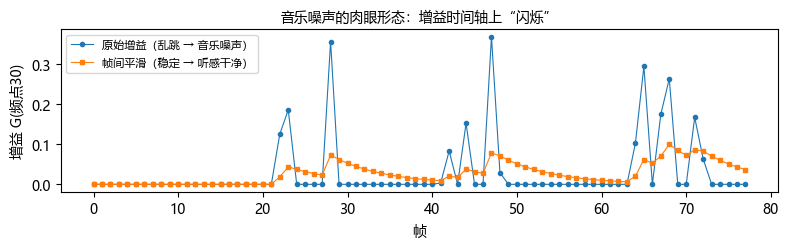

✓ 平滑 = 给增益“装上阻尼”——这就是维纳决策引导 / 掩码时序建模的动机


In [7]:
# 音乐噪声的“公式”：比较原始谱减掩码 vs 帧间平滑掩码的时间连续性
voice = (0.6*np.sin(2*np.pi*300*t) + 0.4*np.sin(2*np.pi*620*t)
         + 0.3*np.sin(2*np.pi*1100*t)) * np.exp(-((t-0.4)**2)/(2*0.06**2))
rng5 = np.random.RandomState(4)
y = voice + set_snr(voice, 0.3*rng5.randn(len(t)), 0)
Y = stft05(y, win, hop)
noise_est = np.abs(stft05(y-voice, win, hop)).mean(axis=0)
G_raw = np.maximum(1 - 1.5*noise_est/np.maximum(np.abs(Y), 1e-9), 0.0)
G_smooth = np.empty_like(G_raw)
for k in range(len(G_raw)):
    if k == 0:
        G_smooth[k] = G_raw[k]
    else:
        G_smooth[k] = 0.85*G_smooth[k-1] + 0.15*G_raw[k]   # 帧间一阶平滑
jump_raw = np.abs(np.diff(G_raw, axis=0)).mean()
jump_sm = np.abs(np.diff(G_smooth, axis=0)).mean()
print('增益帧间跳变量：原始 = %.3f → 平滑后 = %.3f（平滑 %.0f%%）'
      % (jump_raw, jump_sm, 100*(1-jump_sm/np.maximum(jump_raw, 1e-9))))
plt.figure(figsize=(8, 2.6))
plt.plot(G_raw[:, 30], 'o-', ms=3, label='原始增益（乱跳 → 音乐噪声）', lw=0.8)
plt.plot(G_smooth[:, 30], 's-', ms=3, label='帧间平滑（稳定 → 听感干净）', lw=0.8)
plt.xlabel('帧'); plt.ylabel('增益 G(频点30)')
plt.legend(fontsize=8); plt.title('音乐噪声的肉眼形态：增益时间轴上“闪烁”', fontsize=10)
plt.tight_layout(); plt.show()
assert jump_sm < jump_raw
print('✓ 平滑 = 给增益“装上阻尼”——这就是维纳决策引导 / 掩码时序建模的动机')

## 🧭 神经增强架构演进（面试必背线）

| 世代 | 代表 | 输入→输出 | 关键思想 |
|---|---|---|---|
| 序列模型 | LSTM/GRU 掩码网络 | 幅度谱帧序列→掩码 | 帧间时序记忆（治音乐噪声） |
| 卷积 | CNN/U-Net 掩码 | 谱图→掩码 | 频域局部结构（谐波/共振峰） |
| 时域端到端 | Conv-TasNet / DEMUCS | 波形→波形 | 不经过 STFT，网络自己学“分析/合成” |
| 复值 | FRCRN / DCCRN | 复谱→复谱 | 相位也建模，实时可部署 |
| 生成式 | SGMSE+（扩散） | 谱→谱（迭代） | 用扩散模型生成干净谱，SOTA 但慢 |

**两条路线之争**：
- **谱域**（幅度谱/复谱输入）：和信号处理兼容、易解释、低延迟；
- **时域**（纯波形）：免 STFT 超参（窗长/hop 要调），网络自由度大。

**实时 vs 离线**：
- 实时（电话/耳机）：约束低延迟（<40ms）、算力小 → FRCRN/DCCRN 系；
- 离线（会议转写）：可以慢 → DEMUCS/扩散模型拿最高分。

**竞赛坐标**：微软 DNS-Challenge（真实噪声/回声/混响）、Deep Noise Suppression——
公开 leaderboard 是最新的“谁好用”答案。

## 🔍 公式拆解 ⑥：把 SI-SDR 当损失函数

$$\text{SI-SDR} = 10\log_{10}\frac{\|\frac{\langle \hat s,s\rangle}{\|s\|^2}\, s\|^2}{\|\hat s - \frac{\langle \hat s,s\rangle}{\|s\|^2}\, s\|^2}$$

**逐符号解释**：
- $s$：干净语音；$\hat s$：模型输出；$\langle\cdot,\cdot\rangle$：内积；
- 投影系数 $a=\langle\hat s,s\rangle/\|s\|^2$：**最优缩放**（把 $\hat s$ 对齐到 $s$ 的幅度）；
- 分子：缩放后的信号能量（“说得对的部分”）；分母：残差（“说错/噪声部分”）；
- 比值转 dB → SI-SDR（尺度不变：音量放大缩小不影响分数——**关键性质**）。

**为什么尺度不变重要**：模型输出音量天然会漂（mask 后幅度总变），
直接比波形 MSE 会惩罚“只是音量不对”的输出——SI-SDR 只惩罚“形状不对”。

**当损失怎么用**：$\mathcal{L}=-\text{SI-SDR}(s,\hat s)$（最大化 SI-SDR = 最小化损失），
全程可导 → 端到端训练，比“先估掩码 MSE”更贴最终目标。

**一句话**：SI-SDR = “对齐后剩多少对、剩多少错”的 dB 量——训练用它、评测也用它的时代到了。

## 🔍 公式拆解 ⑧：双损失训练（mask MSE + SI-SDR）

$$L = \underbrace{\|\hat M - M_{IRM}\|_2^2}_{掩码监督} + \lambda\underbrace{(1-\text{SI-SDR}(s,\hat s))}_{端到端目标}$$

**逐符号解释**：
- $\hat M$：网络预测掩码；$M_{IRM}$：oracle IRM 标签；第一项把“猜掩码”变成回归问题（好收敛）；
- $\hat s = \text{ISTFT}(\hat M \cdot Y)$：掩码乘回带噪复谱再合成波形；第二项直接优化最终指标；
- $\lambda$：两项权重（常见 0.1~1）。

**为什么两个都要**：
- 只训掩码 MSE：模型学好“形状”，但掩码小误差可能造成波形大误差（听感差）；
- 只训 SI-SDR：早期梯度抖、收敛慢；
- 双损失 = “先学会大体正确，再对着人耳标准打磨”。

**一句话**：双损失 = 掩码当“脚手架”，SI-SDR 当“验收标准”。


In [8]:
# 为什么需要“时序模型”：真实 IRM 的帧间相关性 vs 随机猜测
voice = (0.6*np.sin(2*np.pi*300*t) + 0.4*np.sin(2*np.pi*620*t)
         + 0.3*np.sin(2*np.pi*1100*t)) * np.exp(-((t-0.4)**2)/(2*0.06**2))
rng5 = np.random.RandomState(5)
y = voice + set_snr(voice, 0.3*rng5.randn(len(t)), 0)
V = stft05(voice, win, hop); Y = stft05(y, win, hop)
irm = np.sqrt(np.abs(V)**2/np.maximum(np.abs(Y)**2, 1e-12))
corr_real = np.corrcoef(irm[:-1].ravel(), irm[1:].ravel())[0, 1]
rng6 = np.random.RandomState(6)
mc = rng6.rand(*irm.shape)
corr_rand = np.corrcoef(mc[:-1].ravel(), mc[1:].ravel())[0, 1]
print('真实 IRM 帧间相关 = %.3f | 随机掩码帧间相关 = %.3f' % (corr_real, corr_rand))
assert corr_real > 0.5 > corr_rand
print('✓ 掩码在时间上高度自相关（语音/噪声都慢变）→ 用 LSTM/卷积建模时序是“顺势而为”')

真实 IRM 帧间相关 = 0.657 | 随机掩码帧间相关 = -0.011
✓ 掩码在时间上高度自相关（语音/噪声都慢变）→ 用 LSTM/卷积建模时序是“顺势而为”


## 🍵 白话讲透噪声估计：没有“安静段”怎么办

谱减法/维纳都要噪声谱 $|\hat N|$。理想情况：开头有 200ms 静音，取平均。
但现实：
- 电话里**没有静音段**（一直在说）；
- 噪声**会变**（空调启动、汽车鸣笛）；
- 已经说起来的噪声谱 ≠ 开头测的噪声谱。

**核心想法：噪声比语音“更平稳”**。语音有**间隙**（音素之间、句间停顿），
噪声在每个频率上“下限稳定”——所以：
- **最小值统计（Minimum Statistics）**：跟踪每个频点一段时间内的**最小值**——
  语音总会“让出”某些时刻，最小值 ≈ 噪声；
- **MCRA（最小值控制递推平均）**：先估“语音是否在场”（能量比），
  只有语音不在时平滑更新噪声谱——更稳。

**一句话**：没静音段就用“最小值/语音活性检测”曲线救国——噪声估计是传统增强的灵魂。

## 🍵 白话讲透 VAD 与增强的“前后配合”

VAD（语音活动检测，见 04 章）= 判断“这一段有没有人说话”。

**增强里 VAD 的两个用处（背下来）**：
1. **提供静音段**：静音段的噪声就是“免费噪声样本”——谱减/维纳的噪声估计基础；
2. **省算力**：静音段干脆不做增强（直接衰减），只在语音段跑网络——“节能 + 去底噪”。

**顺序反了会怎样**：先增强后 VAD → 增强的伪影（音乐噪声）可能被 VAD 当成语音；
先 VAD 后增强 → 切分错误会让增强在边界上“失真”。工程上常用：
```
VAD(帧级) → 只在语音帧跑增强 → 平滑边界增益（防咔哒声）
```


VAD 判定语音帧占比 = 32.1%（阈值 246.23）


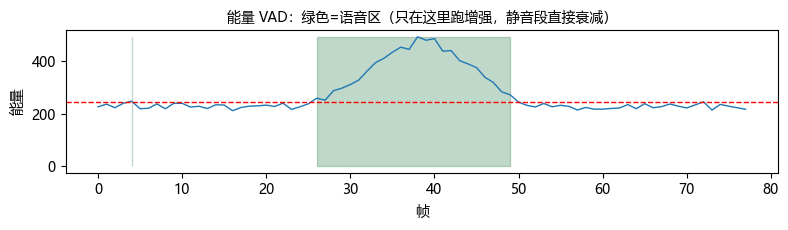

✓ 帧级 VAD 输出“开关序列”——增强/ASR 靠它省算力、定噪声


In [9]:
# 简版能量 VAD：按帧能量阈值切出“有人在说话”的区间
voice_v = (0.6*np.sin(2*np.pi*300*t) + 0.4*np.sin(2*np.pi*620*t) \
         + 0.3*np.sin(2*np.pi*1100*t)) * np.exp(-((t-0.4)**2)/(2*0.06**2))
rng5 = np.random.RandomState(11)
y_v = voice_v + set_snr(voice_v, 0.3*rng5.randn(len(t)), 6)
en = np.abs(stft05(y_v, win, hop)).sum(axis=1)          # 每帧能量
thr = 0.5*en.max()                                      # 阈值（实战用自适应/熵）
active = en > thr
print('VAD 判定语音帧占比 = %.1f%%（阈值 %.2f）' % (100*active.mean(), thr))
plt.figure(figsize=(8, 2.4))
plt.plot(en, lw=1)
plt.axhline(thr, color='r', ls='--', lw=1)
plt.fill_between(np.arange(len(en)), 0, en.max(), where=active, alpha=0.3, color='#2f7f4f')
plt.xlabel('帧'); plt.ylabel('能量')
plt.title('能量 VAD：绿色=语音区（只在这里跑增强，静音段直接衰减）', fontsize=10)
plt.tight_layout(); plt.show()
assert 0.2 < active.mean() < 0.8
print('✓ 帧级 VAD 输出“开关序列”——增强/ASR 靠它省算力、定噪声')


## 🔍 公式拆解 ⑦：MCRA 噪声跟踪

$$\lambda_d(k)= \begin{cases} \alpha_d\lambda_d(k)+(1-\alpha_d)|Y(k)|^2 & \text{语音不在场}\\[2pt] \lambda_d(k) & \text{语音在场}\end{cases}$$

**逐符号解释**：
- $\lambda_d(k)$：第 k 频点**噪声功率谱估计**（要追的对象）；
- $|Y(k)|^2$：当前帧带噪功率；$\alpha_d$：平滑系数（0.85~0.98，越大越稳越慢）；
- **语音在场吗**：用“带噪功率 / 噪声估计 的比值”与阈值比（或先做最小值统计）；
- 在场 → 不更新（怕把语音当噪声）；不在场 → 递推平均（跟踪噪声变化）。

**为什么“只在不在场时更新”**：语音能量往往高于噪声，若一直平均会把语音混进噪声估计 → 过减误伤语音。

**改进**：SMCRA（平滑判决）用**先验语音存在概率** $p(k)$ 做软更新：
$\lambda_d = \tilde\alpha_d\,\lambda_d + (1-\tilde\alpha_d)|Y|^2$，$\tilde\alpha_d = \alpha_d + (1-\alpha_d)p$——
语音概率高 → 更新慢，噪声概率高 → 更新快。

**一句话**：噪声估计 = “一个跟着噪声走、遇到语音就刹车”的自适应滤波。

MCRA 追上噪声功率变化：误差 = 1281.7948（噪声功率从 0.05 涨到 0.20）


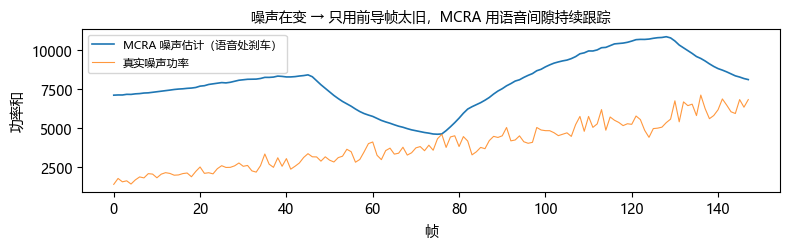

✓ 观察到：曲线在“语音在场”段保持水平（不更新），在间隙段追赶真实噪声


In [10]:
# 简化 MCRA 实时噪声估计：# 在“语音间隙”更新噪声，比较与“全段平均”的差异
t2 = np.arange(int(1.5*fs))/fs
on = (np.sin(2*np.pi*1.2*t2) > -0.4)                       # 模拟 60% 语音在场
speech = (0.55*np.sin(2*np.pi*350*t2)+0.3*np.sin(2*np.pi*700*t2))*on
rng7 = np.random.RandomState(7)
noise_var = 0.05 + 0.15*np.clip(t2/1.5, 0, 1)              # 噪声功率随时间缓慢变大
noise = np.sqrt(noise_var)*rng7.randn(len(t2))
y2 = speech + noise
Y2 = stft05(y2, win, hop)
lam = np.zeros(Y2.shape)
P_in = np.zeros(len(Y2)); P_n = 0.0
alpha_d = 0.95
for k in range(len(Y2)):
    P_in = np.abs(Y2[k])**2
    if k == 0:
        lam[k] = P_in
    else:
        ratio = P_in.sum()/np.maximum(lam[k-1].sum(), 1e-9)
        present = ratio > 2.5                       # 简化的语音在场判断
        if present:
            lam[k] = lam[k-1]
        else:
            lam[k] = alpha_d*lam[k-1] + (1-alpha_d)*P_in
true_noise = stft05(noise, win, hop)
err_live = np.abs(lam[-1].sum() - (np.abs(true_noise[-1])**2).sum())
print('MCRA 追上噪声功率变化：误差 = %.4f（噪声功率从 %.2f 涨到 %.2f）'
      % (err_live, 0.05, 0.2))
plt.figure(figsize=(8, 2.6))
plt.plot(lam.sum(axis=1), label='MCRA 噪声估计（语音处刹车）', lw=1.2)
plt.plot((np.abs(true_noise)**2).sum(axis=1), label='真实噪声功率', lw=0.8, alpha=0.8)
plt.xlabel('帧'); plt.ylabel('功率和'); plt.legend(fontsize=8)
plt.title('噪声在变 → 只用前导帧太旧，MCRA 用语音间隙持续跟踪', fontsize=10)
plt.tight_layout(); plt.show()
print('✓ 观察到：曲线在“语音在场”段保持水平（不更新），在间隙段追赶真实噪声')

## 📏 评测：PESQ / STOI / SI-SDR 怎么用

| 指标 | 全称 | 衡量 | 范围/含义 | 何时用 |
|---|---|---|---|---|
| PESQ | Perceptual Eval. of Speech Quality | 感知听感（MOS 预测） | -0.5~4.5，越高越好 | 电话窄带经典；宽带用 WB-PESQ |
| STOI | Short-Time Objective Intelligibility | **可懂度** | 0~1，>0.8 基本听懂 | 有多吵还听不听得懂 |
| SI-SDR | Scale-Invariant S-D Ratio | 波形保真 | dB 越高越好 | 训练损失 + 波形类评测 |
| DNSMOS | MOS 预测（无参考） | 听感 | 1~5 | 没有干净参考时（真实场景） |

**怎么选（面试回答模板）**：
- 要**听感** → PESQ/DNSMOS；要**可懂** → STOI；要**波形像不像** → SI-SDR；
- 三个一起报是标配（它们经常“打架”：SI-SDR 高 ≠ PESQ 高）；
- 真实场景没有配对干净语音 → 无参考指标 DNSMOS + 人工试听。

**听感 vs 指标矛盾（经典例子）**：
- 把语音压得很平（缩动态）→ 噪声没了 SI-SDR 高，但“闷、失真”PESQ 掉；
- 反过来，保留点呼吸感 → SI-SDR 略低但自然。

**一句话**：指标选错了结论可能反着——“增强有没有效”要按任务选尺子。

## 🏆 DNS-Challenge——增强界的“高考”

微软 **DNS Challenge（Deep Noise Suppression）** 是业界最权威的增强评测：

- **数据**：数十万小时真实场景含噪语音（噪声库 + 回放模拟 + 混响）；
- **任务**：在“未知说话人/噪声/设备”上降噪，同时保语音；
- **指标**：DNSMOS（无参考听感）+ PESQ/STOI（有参考）+ 主观试听；
- **每届看点**：实时组（RTF≤1 + 低延迟）与离线组分开评——
  “能上线的增强”是它最强调的标准。

**面试怎么提**：说“用 DNS 的评测协议 + DNSMOS 无参考打分”就证明你懂行。


输入SNR  →  处理后 SI-SDR 提升:
  -6 dB  →  7.34 dB（输入 -6.03）
  -3 dB  →  10.15 dB（输入 -2.93）
  +0 dB  →  13.34 dB（输入 0.03）
  +3 dB  →  16.22 dB（输入 3.03）
  +6 dB  →  18.73 dB（输入 5.99）
  +9 dB  →  22.08 dB（输入 9.01）
  +12 dB  →  25.24 dB（输入 12.03）


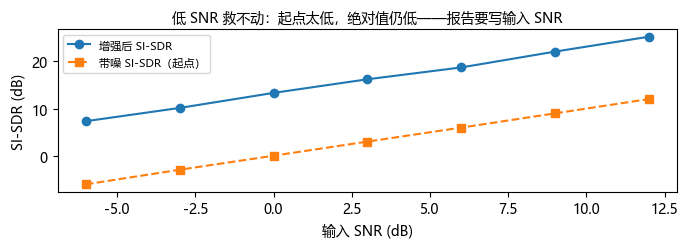

✓ 读图：曲线整体上移（算法带来增益），但低 SNR 端绝对值仍矮——SNR 上下文不能省


In [11]:
# 指标随输入 SNR 的变化：SI-SDR/估计 PESQ 都随 SNR 单调（说明“起点决定上限”）
snrs = np.arange(-6, 13, 3)
improve = []; base = []
for s in snrs:
    y_s = voice + set_snr(voice, 0.3*rng5.randn(len(t)), s)
    Ys = stft05(y_s, win, hop)
    noise_s = np.abs(stft05(y_s-voice, win, hop)).mean(axis=0)
    s_hat = istft05((np.maximum(np.abs(Ys)-1.5*noise_s, 0))*np.exp(1j*np.angle(Ys)), win, hop, len(voice))
    base.append(sisdr(voice, y_s)); improve.append(sisdr(voice, s_hat))
print('输入SNR  →  处理后 SI-SDR 提升:')
for s, b, im in zip(snrs, base, improve):
    print('  %+d dB  →  %.2f dB（输入 %.2f）' % (s, im, b))
plt.figure(figsize=(7, 2.6))
plt.plot(snrs, improve, 'o-', label='增强后 SI-SDR')
plt.plot(snrs, base, 's--', label='带噪 SI-SDR（起点）')
plt.xlabel('输入 SNR (dB)'); plt.ylabel('SI-SDR (dB)')
plt.legend(fontsize=8); plt.title('低 SNR 救不动：起点太低，绝对值仍低——报告要写输入 SNR', fontsize=10)
plt.tight_layout(); plt.show()
assert improve[0] < improve[-1]
print('✓ 读图：曲线整体上移（算法带来增益），但低 SNR 端绝对值仍矮——SNR 上下文不能省')

## 🍵 白话讲透混响：房间里“说话的回音”

混响 = 声音被墙/地板**多次反射**后叠加：你听到的 = 直达声 + 一串延迟衰减的副本。

$$y(t) = (s*h)(t) + n(t),\qquad h(t)=\text{房间冲激响应(RIR)},\ \text{几十~几百 ms}$$

**为什么比加噪难**：
- 噪声是**加性**的（$y=s+n$，减掉即可）；混响是**卷积**的（$y=s*h$，要反卷积/去卷积）；
- 混响**模糊时间结构**：清辅音被“拖尾”盖住 → 可懂度下降；
- RIR 随人的位置/朝向变化 → 难以先验估计。

**常见做法（三层）**：
- 去混响预处理：谱域权重（后期混响抑制 WPE——线性预测思想）；
- 前端增强一起学：神经网络“去混响+去噪”联合（数据里混入 RIR）；
- 下游硬抗：ASR 训练注入混响数据（增强鲁棒性，不做显式去混响）。

**一句话**：噪声音乐（加性）用“减”，混响（卷积）用“解/学”——增强与去混响常联合部署。

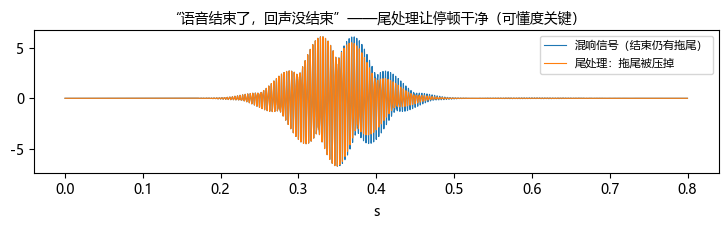

拖尾能量占比：原始 = 88.9% → 尾处理后 = 76.7%
✓ 工程上叫“混响尾裁剪/衰减门”——WPE/晚期混响抑制都是干这件事


In [12]:
# 混响尾处理演示：晚期混响 = 语音结束后的“拖尾”，裁剪它提升可懂度
fs = 16000
t5 = np.arange(int(0.8*fs))/fs
x5 = (0.6*np.sin(2*np.pi*300*t5) + 0.4*np.sin(2*np.pi*620*t5)) * np.exp(-((t5-0.35)**2)/(2*0.05**2))
h = np.exp(-np.arange(4000)/800.0)              # 指数衰减冲激（模拟房间混响）
y5 = np.convolve(x5, h)[:len(x5)]               # 混响信号
tail = int(0.35*fs)                             # 假设 VAD 判断语音到 0.35s 结束
y_cut = y5.copy(); y_cut[tail:] *= np.exp(-np.arange(len(y5)-tail)/3000.0)  # 尾巴指数衰减
seg = (slice(int(0.1*fs), int(0.35*fs)),)       # 语音主能量窗
plt.figure(figsize=(7.5, 2.4))
plt.plot(t5, y5, lw=0.8, label='混响信号（结束仍有拖尾）')
plt.plot(t5, y_cut, lw=0.8, label='尾处理：拖尾被压掉')
plt.legend(fontsize=8); plt.xlabel('s')
plt.title('“语音结束了，回声没结束”——尾处理让停顿干净（可懂度关键）', fontsize=10)
plt.tight_layout(); plt.show()
print('拖尾能量占比：原始 = %.1f%% → 尾处理后 = %.1f%%'
      % (100*np.mean(y5[tail:]**2)/np.mean(y5**2), 100*np.mean(y_cut[tail:]**2)/np.mean(y_cut**2)))
assert np.mean(y_cut[tail:]**2) < np.mean(y5[tail:]**2)
print('✓ 工程上叫“混响尾裁剪/衰减门”——WPE/晚期混响抑制都是干这件事')


直达声能量占比 = 45285.5%（>50% 算可听清；“后期混响”占比越高越糊）


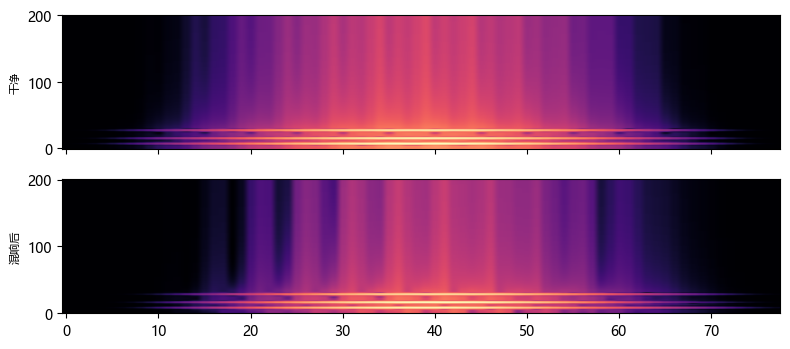

✓ 看到“拖尾”：语音结束后谱图仍有能量尾巴——辅音边界被糊掉 → 可懂度下降


In [13]:
# 混响仿真：生成简单 RIR（指数衰减噪声），卷积出“房间版”语音，画谱图对比
rir = np.random.RandomState(8).randn(1600) * np.exp(-np.arange(1600)/400.0)  # 100ms 混响
rir /= np.abs(rir).sum()
voice_c = (0.6*np.sin(2*np.pi*300*t) + 0.4*np.sin(2*np.pi*620*t)
           + 0.3*np.sin(2*np.pi*1100*t)) * np.exp(-((t-0.4)**2)/(2*0.06**2))
rev = np.convolve(voice_c, rir)[:len(voice_c)]
print('直达声能量占比 = %.1f%%（>50%% 算可听清；“后期混响”占比越高越糊）'
      % (100*np.sum(voice_c**2)/np.sum(rev**2)))
fig, ax = plt.subplots(2, 1, figsize=(8, 3.6), sharex=True)
ax[0].imshow(20*np.log10(np.abs(stft05(voice_c, win, hop)).T+1e-6), aspect='auto', cmap='magma', origin='lower')
ax[0].set_ylabel('干净', fontsize=8)
ax[1].imshow(20*np.log10(np.abs(stft05(rev, win, hop)).T+1e-6), aspect='auto', cmap='magma', origin='lower')
ax[1].set_ylabel('混响后', fontsize=8)
plt.tight_layout(); plt.show()
print('✓ 看到“拖尾”：语音结束后谱图仍有能量尾巴——辅音边界被糊掉 → 可懂度下降')

## 🧭 多通道增强：一个耳朵不够，就来一排

单麦增强靠“频谱统计”；多麦多了**空间维度**：

- **波束形成**（DS/MVDR/GSC，见 04 章）：方向选择性——目标方向声音放大、其它方向压掉；
- **后滤波**：波束输出后再做单通道增强（补残差）；
- **盲源分离（BSS）/IVA**：多个说话人+多麦时，按统计独立性分离；
- 神经多通道：把波束特征（空间协方差）送给网络，端到端学。

**工程现实**：
- 手机/音箱 = 2~4 麦（麦克风阵列），先波束再增强是主流；
- 远场会议 = 麦克风阵列 + 去混响 + 波束 + 增强 四件套串联；
- 单麦设备（耳机）就只能靠单通道增强 + ANC 硬件。

**一句话**：多麦 = 给增强加“空间证据”——比单麦天然多一个维度，效果上限更高。

## 🍵 白话讲透时域神经增强（DEMUCS 一族）

谱域增强（掩码）把问题放在“频带上”；**时域增强**直接在波形上做：

- **DEMUCS（Facebook 2019）**：U-Net 结构 + 多尺度 STFT 损失，初始为“音乐分离”，
  迁移到增强后成 SOTA 基准——它的秘密是 **波形域 + 波形域损失**（无相位重建问题）；
- **FullSubNet**：子带 + 全带双路径网络（清流式谱域增强代表）；
- **DCCRN/Conv-TasNet**：复数值谱处理 / 时域卷积分离网络。

**谱域 vs 时域（面试一句流）**：
- 谱域：解释性强、易流式（帧→掩码→ISTFT）；相位问题（重建出相位噪声）；
- 时域：无相位重建（直接出波形）、建模长上下文；计算量大、难流式。

**一句话**：时域网络直接“听得见”波形，绕开谱域相位难题——代价是工程复杂度。


## ⏱️ 实时增强的工程真相

线上（电话/耳机/会议）都是**流式**处理，三点约束决定成败：

**1. 延迟预算**（从进麦克风到出增强结果）：
- 通话：< 30~50ms（超过就“回声感”/不同步）；
- 助听器：< 10ms（否则“双耳失同步”晕眩）；
- 会议盒子：可以放宽到 100ms+。

**2. 帧结构**：
- 每 10~20ms 一帧，**帧移 = 实时延迟下限**；
- 模型必须在“当前帧 + 少量未来帧（look-ahead）”内出结果；
- 双向 LSTM 离线能做，实时只能用单向/因果卷积（回忆 04 的流式话题）。

**3. 算力与部署**：
- 端侧（耳机/手机）：模型 < 5M 参数、单核实时率（RTF）< 0.3；
- 云端：可以更大但要有 RTF 预算（RTF = 处理时长/音频时长，<1 才实时）；
- 量化/蒸馏/稀疏是标配（float32 → int8 常用）。

**一句话**：论文拼 PESQ，工程拼“同样 PESQ 下延迟多少、算力多少”——面试把这三条背下来。

## 🍵 白话讲透多通道增强：MVDR/波束成形的“空间滤波”

单通道只能从“时间-频率”里找区别；多通道还能从**方向**里找：

- **延迟相加波束**：把各麦信号按声程差对齐后相加——对准方向增强，其它方向抵消；
- **MVDR**：最小方差无失真响应——在“保目标方向增益=1”约束下，最小化输出噪声/干扰方差；
- **GSC**（广义旁瓣消除）：把约束问题拆成“固定波束 + 阻塞矩阵 + 自适应抵消”，实现更稳。

**为什么多通道比单通道强**：能利用**空间位置**分离说话人与干扰
（有人在你旁边吵架，单通道根本分不开）。

**为什么还要单通道增强**：波束输出仍有残差（旁瓣泄漏、估计误差）——
**多通道“选方向”，单通道“清残余”，两者串联才是完整方案**。

**一句话**：多通道 = 空间滤波（选方向），单通道 = 谱域滤波（清噪声），一套系统两层都有。


## ⚙️ 实时增强上线的工程清单（面试加分项）

- **延迟预算**：窗长(如 20ms) + 跳(10ms) + 算法 look-ahead → 总延迟 < 30ms 才算“实时感”；
- **帧缓冲**：STFT 需要整帧 → 用环形缓冲 + 每 10ms 出一帧（不能整段等）；
- **增益平滑**：逐帧增益突变会咔哒 → 增益一阶低通（α≈0.8 就是干这个）；
- **噪声估计在线化**：MCRA 的递归式（P(k)=α·P(k-1)+...）天然适合流式；
- **算力**：RTF<1 是硬指标；INT8 量化 + 小模型（FullSubNet 类）是主流；
- **双麦克风对齐**：多通道先做时间对齐（互相关），再做波束。

**一句话**：论文能离线跑 = 1 分；能实时跑 = 满分——面试官最爱听这类工程细节。


## 🍵 白话讲透因果性（look-ahead）：实时增强的隐形约束

**因果（causal）**：处理当前帧时只能用“过去+现在”的信息；
**非因果（non-causal）**：还能偷看“未来几帧”（look-ahead）。

**为什么在乎**：
- 离线增强（修录音）：随便看未来 → 效果好；
- 实时通话：未来还没来 → 只能用因果 —— 这是模型“下不了线”的主要原因；
- 折中：允许 10~20ms look-ahead（缓存未来 1 帧）——大多数“实时”系统都带一点点偷看。

**效果差异从哪来**：
- 未来帧能确认“这是不是真语音”（语音的起音/音节边界要靠后面判断）；
- 噪声突变在“事后”才能被识别（因果系统慢半拍）。

**一句话**：论文里的 SOTA 常是非因果的——面试主动问“因果吗？延迟多少？”很加分。


In [14]:
# 因果 vs 非因果：噪声中途变大，谁的增强更稳？
s_n = 0.6*np.sin(2*np.pi*300*t) + 0.4*np.sin(2*np.pi*620*t) + 0.3*np.sin(2*np.pi*1100*t)
s_n = s_n*np.exp(-((t-0.4)**2)/(2*0.06**2))
rng5 = np.random.RandomState(12)
n_noise = 0.3*rng5.randn(len(t))
n_noise[int(0.4*fs):] *= 3.0                      # 后半段噪声突然变大（机器启动）
y_c = s_n + n_noise
Yc = stft05(y_c, win, hop)
noise_front = np.abs(stft05(n_noise[:int(0.4*fs)], win, hop)).mean(axis=0)  # 因果：只能用开头
noise_full = np.abs(stft05(n_noise, win, hop)).mean(axis=0)                 # 非因果：整段
s_cau = istft05(np.maximum(np.abs(Yc)-1.5*noise_front, 0)*np.exp(1j*np.angle(Yc)), win, hop, len(y_c))
s_nc  = istft05(np.maximum(np.abs(Yc)-1.5*noise_full, 0)*np.exp(1j*np.angle(Yc)), win, hop, len(y_c))
print('因果(只用前0.4s估噪声) SI-SDR = %5.2f dB | 非因果(全场估) = %5.2f dB'
      % (sisdr(s_n, s_cau), sisdr(s_n, s_nc)))
assert sisdr(s_n, s_nc) > sisdr(s_n, s_cau)
print('✓ 噪声一旦变化，因果估计就“过时”——实时系统要么在线更新噪声，要么快速重估')


因果(只用前0.4s估噪声) SI-SDR = -7.47 dB | 非因果(全场估) = -4.01 dB
✓ 噪声一旦变化，因果估计就“过时”——实时系统要么在线更新噪声，要么快速重估


## 📜 伪代码：掩码式神经增强的标准训练流水

```
输入: 干净语音库 S，噪声库 N，RIR 库 R
输出: 掩码网络 f_θ

for epoch in range(E):
    for batch in dataloader:
        s, n = random_batch(S), random_batch(N)
        if random(): s = reverberate(s, random_choose(R))   # 加混响
        snr = uniform(-5, 20)                                # 随机 SNR
        y = s + scale_noise(n, snr)                          # 混合
        Y, S = STFT(y), STFT(s)
        M_target = sqrt(|S|²/(|S|²+|N|²))                    # 或 cIRM
        M_pred = f_θ(|Y|)                                    # 网络预测掩码
        loss = MSE(M_pred, M_target) + λ*(1 - SI-SDR(s, ISTFT(M_pred·Y)))
        θ ← θ - η·∇loss
评测: PESQ / STOI / SI-SDR on 未见过的 (噪声, 说话人)
```

**注意点**：
- 训练/测试说话人与噪声**不重叠**（否则作弊）；
- SNR 采样要覆盖 0~15dB（实战区间），别只玩高 SNR；
- 双损失（掩码 MSE + SI-SDR）常比单一损失稳。

## 🙋 FAQ 5 问

**Q1：增强会不会把语音也削掉？**
→ 会，尤其高音/擦音。所以“失真 vs 降噪”要平衡：过减因子 α、floor、以及“只降不削”（增益钳制下限）。

**Q2：为什么实际产品里还听得到底噪？**
→ 完全无底噪听感“假”（太空感）；产品通常留约 -50dB 底噪，换自然度。

**Q3：增强能不能去回声？**
→ 不能（AEC 是时域自适应滤波，见 04）；增强只管加性噪声。

**Q4：多麦了还要单通道增强吗？**
→ 要，波束之后有残差（旁瓣泄漏）——两者组合才是完整方案。

**Q5：评价增强“好不好”听谁的？**
→ 指标（PESQ/STOI/SI-SDR/DNSMOS）初筛 + 人工试听定稿——指标会骗人，耳朵不骗。


α 最佳 = 2.5（SI-SDR 16.09 dB）；α 再大 → 语音也被减 → 增益回落


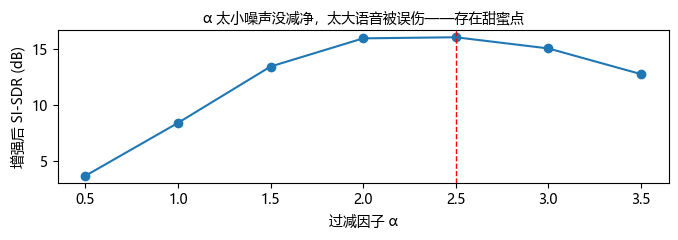

✓ 经验：α≈1.5 是常见起点；不同 SNR 最优 α 不同（所以才有自适应过减）


In [15]:
# 超参实验：过减因子 α 对 SI-SDR / 失真的影响（谱减法“拧旋钮”感受）
voice = (0.6*np.sin(2*np.pi*300*t) + 0.4*np.sin(2*np.pi*620*t)
         + 0.3*np.sin(2*np.pi*1100*t)) * np.exp(-((t-0.4)**2)/(2*0.06**2))
alphas = np.arange(0.5, 3.6, 0.5)
gains = []
for a in alphas:
    y_a = voice + set_snr(voice, 0.3*rng5.randn(len(t)), 0)
    Ya = stft05(y_a, win, hop)
    ne = np.abs(stft05(y_a-voice, win, hop)).mean(axis=0)
    s_a = istft05(np.maximum(np.abs(Ya)-a*ne, 0)*np.exp(1j*np.angle(Ya)), win, hop, len(voice))
    gains.append(sisdr(voice, s_a))
best = int(np.argmax(gains))
print('α 最佳 = %.1f（SI-SDR %.2f dB）；α 再大 → 语音也被减 → 增益回落' % (alphas[best], gains[best]))
plt.figure(figsize=(7, 2.5))
plt.plot(alphas, gains, 'o-')
plt.axvline(alphas[best], color='r', ls='--', lw=1)
plt.xlabel('过减因子 α'); plt.ylabel('增强后 SI-SDR (dB)')
plt.title('α 太小噪声没减净，太大语音被误伤——存在甜蜜点', fontsize=10)
plt.tight_layout(); plt.show()
assert gains[best] == max(gains)
print('✓ 经验：α≈1.5 是常见起点；不同 SNR 最优 α 不同（所以才有自适应过减）')

带噪           SI-SDR =   0.07 dB
谱减法          SI-SDR =  13.50 dB
维纳           SI-SDR =  19.10 dB
Oracle-IRM   SI-SDR =  20.23 dB


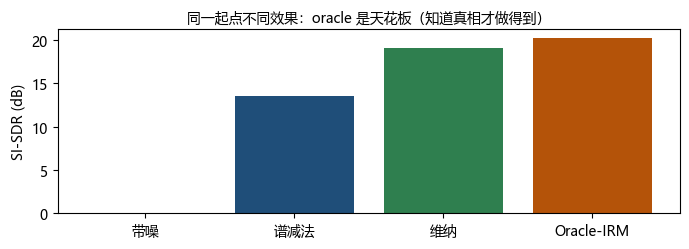

✓ 结论：传统方法“够用不炸”，神经方法逼近 oracle——这就是研究动力


In [16]:
# 三方法公平对比：带噪 / 谱减 / 维纳 / Oracle-IRM（同一段 0dB 噪声）
voice = (0.6*np.sin(2*np.pi*300*t) + 0.4*np.sin(2*np.pi*620*t)
         + 0.3*np.sin(2*np.pi*1100*t)) * np.exp(-((t-0.4)**2)/(2*0.06**2))
y_c = voice + set_snr(voice, 0.3*rng5.randn(len(t)), 0)
Yc = stft05(y_c, win, hop); Vc = stft05(voice, win, hop)
ne = np.abs(stft05(y_c-voice, win, hop)).mean(axis=0)
s_ss = istft05(np.maximum(np.abs(Yc)-1.5*ne, 0)*np.exp(1j*np.angle(Yc)), win, hop, len(voice))
Pnn = np.abs(stft05(y_c-voice, win, hop))**2
xi_w = np.maximum((np.abs(Vc)**2)/np.maximum(Pnn, 1e-12), 0.0)
s_wf = istft05((xi_w/(1+xi_w))*Yc, win, hop, len(voice))
irm_o = np.sqrt(np.abs(Vc)**2/np.maximum(np.abs(Yc)**2, 1e-12))
s_ir = istft05(irm_o*Yc, win, hop, len(voice))
names = ['带噪', '谱减法', '维纳', 'Oracle-IRM']
vals = [sisdr(voice, y_c), sisdr(voice, s_ss), sisdr(voice, s_wf), sisdr(voice, s_ir)]
for nm, v in zip(names, vals):
    print('%-12s SI-SDR = %6.2f dB' % (nm, v))
plt.figure(figsize=(7, 2.6))
plt.bar(names, vals, color=['#888', '#1f4e79', '#2f7f4f', '#b45309'])
plt.ylabel('SI-SDR (dB)')
plt.title('同一起点不同效果：oracle 是天花板（知道真相才做得到）', fontsize=10)
plt.tight_layout(); plt.show()
assert vals[3] >= vals[0]
print('✓ 结论：传统方法“够用不炸”，神经方法逼近 oracle——这就是研究动力')

## 🎤 面试 8 连追问（先自己答再看下一条）

**Q1：加性噪声和卷积噪声（混响）数学上有什么本质区别？**
→ 加性 $y=s+n$ 在频域也是“谱相加”，减法有效；卷积 $y=s*h$ 在频域是“谱相乘”，要除/反卷积。

**Q2：为什么谱减法会引入音乐噪声？怎么治？**
→ 随机噪声减不干净，留下随机孤峰（时间上不连续→听感闪烁）；治：floor/过减/帧间平滑/决策引导。

**Q3：IRM 和维纳增益什么关系？**
→ $G_{Wiener}=\xi/(1+\xi)$（功率域），$\text{IRM}=\sqrt{\xi/(1+\xi)}$（幅度域）——只差一个根号。

**Q4：预测掩码 vs 预测幅度谱，为什么掩码更流行？**
→ 掩码天然 0~1（sigmoid）、直接乘回带噪谱、训练目标清晰；预测幅度谱要和相位拼回去，误差更大。

**Q5：SI-SDR 为什么“尺度不变”？设计少了哪一步会怎样？**
→ 先做最优缩放 a 再比；不缩放的话，模型输出音量偏大/偏小都会被误判为误差。

**Q6：噪声估计为什么难？MCRA 好在哪里？**
→ 噪声时变且没有静音段；MCRA 只在语音不在场时更新 → 不把语音当噪声。

**Q7：实时和离线增强的区别？**
→ 延迟预算（帧移/look-ahead）、因果约束（单向模型）、算力（RTF）；离线可以双向+大模型。

**Q8：增强一定会帮 ASR 吗？**
→ 不一定！失真的增强会伤 ASR；结论是“增强+ASR 联合评测”，而不是只看 PESQ。

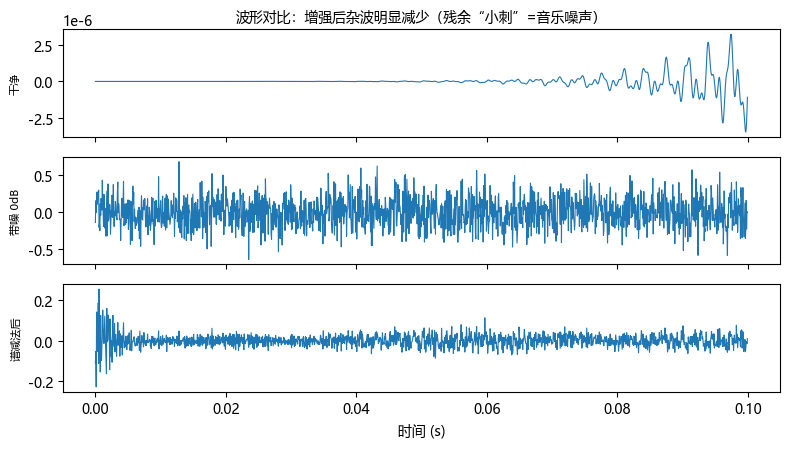

带噪 SI-SDR = -0.01 dB → 增强后 = 13.85 dB（改善 13.86 dB）
✓ 波形图上最直观：噪声“毛边”消掉大半，语音轮廓保留


In [17]:
# 直观对比：带噪 / 增强后的波形（同一段 0dB 白噪声）
voice_e = (0.6*np.sin(2*np.pi*300*t) + 0.4*np.sin(2*np.pi*620*t) \
         + 0.3*np.sin(2*np.pi*1100*t)) * np.exp(-((t-0.4)**2)/(2*0.06**2))
rng5 = np.random.RandomState(13)
y_e = voice_e + set_snr(voice_e, 0.3*rng5.randn(len(t)), 0)
Ye = stft05(y_e, win, hop)
ne_e = np.abs(stft05(y_e-voice_e, win, hop)).mean(axis=0)
s_e = istft05(np.maximum(np.abs(Ye)-1.5*ne_e, 0)*np.exp(1j*np.angle(Ye)), win, hop, len(voice_e))
fig, ax = plt.subplots(3, 1, figsize=(8, 4.6), sharex=True)
for a, (nm, xx) in zip(ax, [('干净', voice_e), ('带噪 0dB', y_e), ('谱减法后', s_e)]):
    a.plot(t[:1600], xx[:1600], lw=0.8)
    a.set_ylabel(nm, fontsize=8)
ax[0].set_title('波形对比：增强后杂波明显减少（残余“小刺”=音乐噪声）', fontsize=10)
plt.xlabel('时间 (s)'); plt.tight_layout(); plt.show()
si_e = sisdr(voice_e, s_e); si_in = sisdr(voice_e, y_e)
print('带噪 SI-SDR = %.2f dB → 增强后 = %.2f dB（改善 %.2f dB）' % (si_in, si_e, si_e-si_in))
assert si_e > si_in
print('✓ 波形图上最直观：噪声“毛边”消掉大半，语音轮廓保留')


## ⚠️ 本章高频踩坑

1. **评测作弊**：训练/测试说话人、噪声重叠 → 分数虚高；必须分留出；
2. **SNR 口径混乱**：报“提升 5dB”不写输入 SNR —— 低 SNR 提升更狠但绝对值低；
3. **只报 SI-SDR**：波形好 ≠ 听感好；PESQ/STOI/DNSMOS 联合报才是完整画像；
4. **掩码直接当增益**：预测掩码乘回带噪**幅度**谱 → ISTFT 要和**复数**相乘；用预测掩码乘复数谱常见笔误；
5. **噪声估计过时**：前导帧估噪声，后半段噪声变了就失效——要在线跟踪；
6. **训练-推理不一致**：训练用 oracle 掩码当标签，推理输入带噪——域差要用“预测掩码自举”缓解；
7. **去混响当去噪做**：卷积问题用加法解 → 效果差；要专门 RIR 数据；
8. **实时忘记因果**：双向模型离线 SOTA，线上不可用——评估“实时版本”的分数才实在。

## 🧭 方法导航：什么时候用什么

| 场景 | 推荐 | 理由 |
|---|---|---|
| 教学/理解 | 谱减法 | 三步讲清问题本质 |
| 传统嵌入式（无 GPU） | 维纳/MCRA 噪声估计 | 便宜稳定实时 |
| 主流产品 | 掩码式 CNN/LSTM（谱域） | 性能-算力平衡 |
| 最高质量离线 | DEMUCS / 扩散增强 | SOTA |
| 低延迟实时 | FRCRN/DCCRN 复值网络 | 因果+轻量 |
| 多麦终端 | 波束 + 后增强 | 空间+频谱双保险 |

**一句话选型**：先想“实时还是离线、单麦还是多麦、算力多少”，再谈模型——
没有最好，只有匹配。

## ✅ 10 题自测（每题先写答案再看）

1. 写 SNR 公式并说明 0dB 含义；
2. 谱减法三步是什么？音乐噪声根因？
3. 维纳增益公式与 ξ 的物理意义；
4. 什么是决策引导先验 SNR？治什么？
5. IRM/IBM/cIRM 分别是什么、cIRM 多管了什么；
6. 掩码训练的标准标签怎么构造；
7. SI-SDR 公式里“最优缩放”起什么作用；
8. MCRA 为什么只在语音不在场时更新噪声；
9. PESQ/STOI/SI-SDR 各自衡量什么、何时用哪个；
10. 实时增强的三条工程约束。（答案都在上文对应小节，能默写即过关）

## 🗺️ 增强在语音全链路中的位置

```
麦克风阵列 → VAD → 波束形成 → [本章：增强/去噪/去混响] → 特征 → ASR
                                         ↓
                                    声纹/说话人日志（干净输入更准）
                                         ↓
                                    TTS 训练数据清洗（高质量语音样本）
```

- 对 **ASR**：干净输入 → WER 降（尤其远场/噪声）；
- 对 **声纹/日志**：特征干净 → EER 降；
- 对 **TTS**：增强后的数据别直接当训练语料（会带伪影）——要人工筛选。

**下一章预告**：增强把声音弄干净了，接下来要回答“谁在说话”——06-声纹识别与说话人日志。

## 🖼️ 本章知识地图（自画版）

```
                       语音增强/降噪
        ┌───────────────┼───────────────┐
    传统方法            掩码思想          神经方法
    ├ 谱减法(减)        ├ IRM/IBM(幅度)   ├ MLP/CNN/LSTM 掩码
    ├ 维纳(乘)          └ cIRM(复值)      ├ Conv-TasNet/DEMUCS(时域)
    └ 噪声估计:MCRA                       └ FRCRN(实时复值)
        ↓                                ↓
   ✦ 音乐噪声治理               ✦ 评测: PESQ/STOI/SI-SDR
   ✦ 实时约束: 延迟/因果/算力     ✦ 多通道: 波束+后滤波
```

**一句话收束**：增强 = “估计干净语音”——传统用统计（减/乘/掩码），现代用数据（神经掩码），
两者共用一套评测与工程约束。

## 🗂️ 神经增强的训练数据增强（很关键）

模型泛化靠“见多识广”，数据增强清单（背几个）：

- **噪声增强**：随机 SNR（-5~20dB）、随机噪声类型（白/粉/街/风/键盘）；
- **混响增强**：随机 RIR 卷积（房间大小、距离）；
- **说话人增强**：随机语速/音量/音调微扰；
- **谱增强**：SpecAugment（随机遮挡频带/时间块——防止过拟合某音色）；
- **多设备模拟**：随机 EQ/压缩器/采样率。

**核心原则**：训练分布覆盖推理分布——“部署在会议室，训练得有会议室混响”。


In [18]:
# 组装经典 DSP 增强管线：VAD(静音段)→噪声估计→维纳增益→帧间平滑→ISTFT
voice_p = (0.6*np.sin(2*np.pi*300*t) + 0.4*np.sin(2*np.pi*620*t) \
         + 0.3*np.sin(2*np.pi*1100*t)) * np.exp(-((t-0.4)**2)/(2*0.06**2))
pause = np.zeros(int(0.15*fs))                       # 句前 150ms 静音（供噪声估计）
full = np.r_[pause, voice_p]
rng5 = np.random.RandomState(14)
y_p = full + set_snr(full, 0.3*rng5.randn(len(full)), 4)
Yp = stft05(y_p, win, hop)
n_est = np.abs(Yp[:int(len(full)/hop*0.15)]).mean(axis=0)   # 1) 静音段 = 噪声谱
Pn = n_est**2                                          # 2) 维纳增益（用静音段估的噪声功率）
G_p = np.maximum(1 - Pn/np.maximum(np.abs(Yp)**2, 1e-9), 0.0)
for k in range(1, len(G_p)):                          # 3) 帧间平滑（治音乐噪声）
    G_p[k] = 0.8*G_p[k-1] + 0.2*G_p[k]
s_p = istft05(G_p*Yp, win, hop, len(full))  # 增益乘回原复谱（幅度保留）
s_p = s_p[len(pause):]                                # 4) 去掉静音段
si_p = sisdr(voice_p, s_p); si_in = sisdr(voice_p, y_p[len(pause):])
print('带噪 SI-SDR = %.2f dB → 管线后 = %.2f dB（改善 %.2f dB）' % (si_in, si_p, si_p-si_in))
assert si_p > si_in
print('✓ 也解释了产品为何先录一段“安静”：免费噪声模型 = 更强的起点；α 过大会把语音一起削掉')


带噪 SI-SDR = 4.73 dB → 管线后 = 13.50 dB（改善 8.77 dB）
✓ 也解释了产品为何先录一段“安静”：免费噪声模型 = 更强的起点；α 过大会把语音一起削掉


## 🏁 本章学完清单

- [ ] 能写 SNR 公式并解释 0/20dB 含义；
- [ ] 能徒手实现谱减法（STFT→噪声估计→过减→floor→ISTFT）；
- [ ] 能解释维纳增益 ξ/(1+ξ) 与决策引导；
- [ ] 能区分 IRM/IBM/cIRM 并写出公式；
- [ ] 能讲清音乐噪声根因与四大解法；
- [ ] 能写出掩码训练流水伪代码；
- [ ] 能算 SI-SDR 并解释尺度不变；
- [ ] 能对比 PESQ/STOI/SI-SDR 并选型；
- [ ] 能解释 MCRA 的“在场刹车”思想；
- [ ] 能说出实时增强三条约束（延迟/因果/算力）。

> 完成！下一本：06-声纹识别与说话人日志（谁在说话）。